In [1]:
import requests
import gzip
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
from  scipy import sparse 

In [2]:
url = "https://snap.stanford.edu/data/wiki-Vote.txt.gz"
respuesta = requests.get(url) #descargamos los datos  
with open("datos.txt.gz", "wb") as datos : #Los datos inicialmente vienen en formato gzip
    datos.write(respuesta.content)

In [3]:
#Descomprimir los datos 
with gzip.open("datos.txt.gz", "rt") as archivo_gzip: #Leemos el archivo como string,no como bytes
     grafo = nx.read_edgelist(archivo_gzip, comments="#", delimiter = "\t", nodetype = int,create_using =nx.DiGraph())
    #La linea anterior ,ignora los comentarios ,los saltos de linea y crea usando grafo dirigido 

In [4]:
# ESTADISTICAS
aristas = (grafo.number_of_edges()) #Numero de aristas 
cantidad_nodos = (grafo.number_of_nodes()) 
grado_entrada_medio =  (sum(dict(grafo.in_degree()).values())/cantidad_nodos) #Sumamos la cantidad de entrantes y la dividimos en cantidad de nodos
grado_salida_medio = sum(dict(grafo.out_degree()).values())/cantidad_nodos
nodos_colgantes = sum(1 for nodo in grafo.nodes() if grafo.out_degree(nodo) == 0) #Sin aristas de salida
densidad_red = aristas / (cantidad_nodos * (cantidad_nodos-1))

In [5]:
# nodo de mayor grado 
valores_grados_nodos = dict(grafo.in_degree())
nodo_mayor_grado_entrada = int(max(valores_grados_nodos, key = valores_grados_nodos.get))
print(F"El nodo {nodo_mayor_grado_entrada}  tiene {max(valores_grados_nodos.values())} conexiones que llegan a el  ")

El nodo 4037  tiene 457 conexiones que llegan a el  


In [6]:
estadisticas = pd.DataFrame(data = {"Metricas" : ["Cantidad aristas","Cantidad de nodos",
                                                  "Grado_entrada_medio","Grado_salida_medio",
                                                  "Nodo_mayor_grado_entrada","Cantidad_Nodos_Colgantes",
                                                  "Densidad de la red"],
                                   "Valor" : [(aristas), cantidad_nodos,grado_entrada_medio,
                                              grado_salida_medio, nodo_mayor_grado_entrada, 
                                          nodos_colgantes ,densidad_red]})
estadisticas

,Metricas,Valor
0,Cantidad aristas,103689.000000
1,Cantidad de nodos,7115.000000
2,Grado_entrada_medio,14.573296
3,Grado_salida_medio,14.573296
4,Nodo_mayor_grado_entrada,4037.000000
5,Cantidad_Nodos_Colgantes,1005.000000
6,Densidad de la red,0.002049


# Que la densidad de la red sea más cercana a 0,quiere decir que la mayoria de los nodos estan separados entre si .Si fuera mas cercana a 1,significaria que la mayoria esta conectados entre si.

# P3 

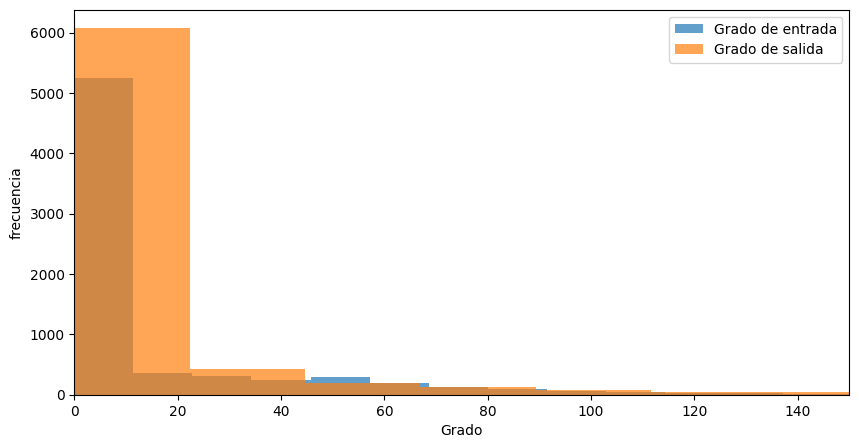

In [7]:
# Grafico de distribución de grado de entrda y del grado de salida  
grado_entrada = list(dict(grafo.in_degree()).values())
grado_salida = list(dict(grafo.out_degree()).values())
plt.figure(figsize = (10,5) )
plt.hist(grado_entrada, bins = 40, alpha = 0.7, label = "Grado de entrada")
plt.hist(grado_salida, bins = 40, alpha = 0.7, label = "Grado de salida")
plt.xlim(0,150)
plt.legend()
plt.ylabel("frecuencia")
plt.xlabel("Grado")
plt.show()

In [8]:
#3.b) Identificacion nodos colgantes 
nodos_colgantes_indentificados = [nodo for nodo in grafo.nodes() if grafo.out_degree(nodo) == 0]
df_nodos_colgantes = pd.DataFrame(nodos_colgantes_indentificados, columns = ["Id_Nodos_colgantes"])
df_nodos_colgantes

,Id_Nodos_colgantes
0,1412
1,7478
2,214
3,271
4,286
...,...
1000,7973
1001,7982
1002,8015
1003,8076


## Dejamos todos los nodos colgantes en un DataFrame identificados por ID, ademas tenemos que son 1005 .

In [9]:
# 3.C)Nodos  mayor grado entrada 
pd.DataFrame(sorted(dict(grafo.in_degree()).items(),key = lambda x: x[1],reverse = True)[0:10], columns = ["ID_Nodo", "Grado entrada"])

,ID_Nodo,Grado entrada
0,4037,457
1,15,361
2,2398,340
3,2625,331
4,1297,309
5,2565,274
6,762,272
7,2328,266
8,5254,265
9,3352,264


# Problematica de nodos colgantes 
- Un nodo colgante es aquel que tiene grado de salida igual a 0,por lo que quiere decir que no contiene enlaces a otro nodo, en el contexto de marcha aleatoria genera un problema,ya que si se llega a este nodo ,entonces se quedaría atrapado sin poder continuar 

# Como se resuelve con la matriz columna estocastica S ?
- Al reparar artificialmente las columnas que son 0 ,por una probabilidad de 1/n (n es la cantidad de nodos),garantiza que el "caminante aleatorio" nunca se quede atrapado. 

In [10]:
# 3.c Nodos mayor grado salida 
pd.DataFrame(sorted(dict(grafo.out_degree()).items(),key = lambda x: x[1],reverse = True)[0:10], columns = ["ID_Nodo", "Grado salida"])

,ID_Nodo,Grado salida
0,2565,893
1,766,773
2,11,743
3,457,732
4,2688,618
5,1166,599
6,1549,587
7,1151,472
8,1374,462
9,1133,399


# 3.d ) Conexa o componentes aisladas? 

In [11]:
nx.is_strongly_connected(grafo)

False

In [12]:
nx.number_strongly_connected_components(grafo)

5816

### Como indica la funcion anteriromente ejecutada,el grafo no es original no es fuertemente conexo.Ademas ,se identificaron 5816 componentes fuertemente conexas ,por lo que la red está formada por multiples subconjuntos que no son alcanzables mediante caminos directos.Sin embargo,esto no impide que se aplique Pagerank,ya que la matriz de Google,introduce una probabilidad positiva entre cualquier par de nodos.

In [13]:
# 4 a) Construccion matriz de Google 
adj_matrix = nx.to_scipy_sparse_array(grafo)
grado_salida_m = np.ravel(adj_matrix.sum(axis = 1))#Me da los grados de salida de cada nodo  y aplana en arrglo unidimensional
with np.errstate(divide = "ignore") : 
    areglo_grado_salida = np.where(grado_salida_m >0, 1/grado_salida_m, 0)
    #Si el grado de salida es mayor a 0,entonces hago la division,sino reemplzo por 0
diag_matriz = sparse.diags(areglo_grado_salida).tocsr() 
H = (diag_matriz @ adj_matrix).T # Es forma altenrativa sale desde el link que se llama LINK IMPORTANTE 

# Por qué cada columna de H suma a 1 cuando el nodo fuente no es colgante? 
-Si el nodo no es colgante,quiere decir que su grado de salida es estrictamente positivo,ademas dado que cada conexion posee el mismo peso,entonces si fuera el nodo j,cada conexion tendria 1/out(j) de peso ,por lo que al factorizar por las out(j) conexiones,el resultado es 1.

In [14]:
# 4.B ) Construccion matriz columna estocastica 
suma_columnas = np.ravel(H.sum(axis = 0)) 
a = (suma_columnas == 0).astype(float)#me interesan columnas sean 0
N = cantidad_nodos 
S = H.tocsc().copy() #Para modificar la copia y ademas ponemos formato csc ya que es mas rapido en operaciones de columna
for j in np.where(a)[0]: # Me devuelve los indices de las columnas colgantes
    S[:, j] = 1/N #A toda las filas de esa columna colgante se reemplaza con 1/n 
suma_columnas_S = np.ravel(S.sum(axis = 0))
verificar_todas_suma_1 = np.allclose(suma_columnas_S, 1.0) #comprueba que cada columna suma 1
print(f"Todas suman las columnas suman 1 ? {verificar_todas_suma_1}")


C:\Users\pokem\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Todas suman las columnas suman 1 ? True


In [15]:
# parte 4.c ) 
alpha = 0.85  # amortiguacion 

# El valor de amortigumiento es un valor estandar ,donde representa que 85% de las veces el usuario se mantiene en su nodo y el 15% de las veces realiza un salto aleatorio a cualquier otro,esto evita que no se quede atrapado en ciclo y garatiza asi que la matriz tenga una distribucion estacionaria.

# Se evita construir G directamente debido al tamaño de la matriz ,sin embargo en  la iteracion de potencias se implemnta la multiplicacion usando la expresion equivalente.

# Calculamos ahora el PageRank con el algoritmo de iteracion de potencias

In [16]:
n = grafo.number_of_nodes()
epsilon = 1e-10

# vector inicial uniforme
r = np.ones(n) / n

errores = []
iteraciones = 0

while True:

    r_nuevo = alpha * (S @ r) + (1-alpha)/n

    error = np.linalg.norm(r_nuevo-r,1)

    errores.append(error)

    iteraciones += 1

    if error < epsilon:
        break

    r = r_nuevo

pagerank = r_nuevo

print("Iteraciones:", iteraciones)
print("Error final:", error)

Iteraciones: 29
Error final: 9.084639702831854e-11


# Graficaremos la convergencia y verificaremos si el decrecimiento es geometrico con razon aproximada de α

# primero iteramos de nuevo guardando la distancia con el vector final

In [17]:
r = np.ones(n)/n

errores_reales = []

while True:

    errores_reales.append(np.linalg.norm(r-pagerank,1))

    r_nuevo = alpha*(S@r) + (1-alpha)/n

    if np.linalg.norm(r_nuevo-r,1) < epsilon:
        break

    r = r_nuevo

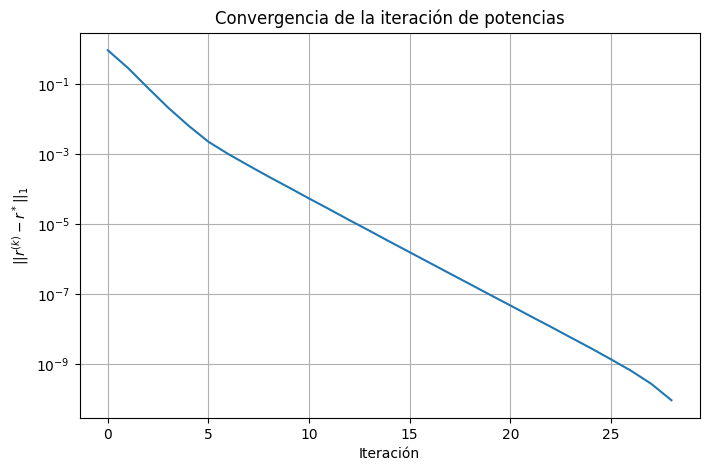

Razón promedio: 0.4927932075420598
Razón promedio: 0.4807519611680456


In [21]:
plt.figure(figsize=(8,5))

plt.semilogy(errores_reales)

plt.xlabel("Iteración")
plt.ylabel(r"$||r^{(k)}-r^*||_1$")
plt.title("Convergencia de la iteración de potencias")

plt.grid(True)

plt.show()

razones = []

for i in range(len(errores_reales)-1):
    razones.append(errores_reales[i+1]/errores_reales[i])

print("Razón promedio:", np.mean(razones[8:18])) #usamos el promdeio de las de al medio para que no domine el segundo autovalor
print("Razón promedio:", np.mean(razones[-20:])) #aun asi podemos ver q es casi el mismo q si usamos los ultimos 20

# Podemos ver que si se comporta de manera geometrica sin embargo la razon observada es casi 0.5 la cual es mucho mas rapida que el amortiguamiento teorico que nos mostraba nuestro α= 0.85

# Verificamos las propiedades de modulo de (r_1)* = 1 y que r_i* > 0 para todo i.

In [29]:
print(np.linalg.norm(pagerank,1))
print(np.min(pagerank))


0.9999999999999998
5.048837521544702e-05


# Se cumple que la norma del Page Rank es 1 y que para todo i los valores son mayores a 1 ya que nuestro min es 5.048837521544702e-05 lo cual es mayor a 0

# Tabla 20 mayores PageRank

In [36]:

grado_entrada_dict = dict(grafo.in_degree())
grado_salida_dict = dict(grafo.out_degree())


nodos = list(grafo.nodes())


in_degree = np.array([grado_entrada_dict[n] for n in nodos])
out_degree = np.array([grado_salida_dict[n] for n in nodos])

In [37]:
ranking = np.argsort(-pagerank)

top20 = [nodos[i] for i in ranking[:20]]

tabla = pd.DataFrame({
    "Rank": range(1, 21),
    "Nodo": top20,
    "PageRank": pagerank[ranking[:20]],
    "Grado entrada": [grado_entrada_dict[n] for n in top20],
    "Grado salida": [grado_salida_dict[n] for n in top20]
})

tabla

,Rank,Nodo,PageRank,Grado entrada,Grado salida
0,1,4037,0.004607,457,15
1,2,15,0.003680,361,50
2,3,6634,0.003587,203,3
3,4,2625,0.003284,331,0
4,5,2398,0.002609,340,62
5,6,2470,0.002524,149,0
6,7,2237,0.002497,181,241
7,8,4191,0.002268,259,20
8,9,7553,0.002170,190,0
9,10,5254,0.002150,265,33


# PageRank VS Grado de entrada

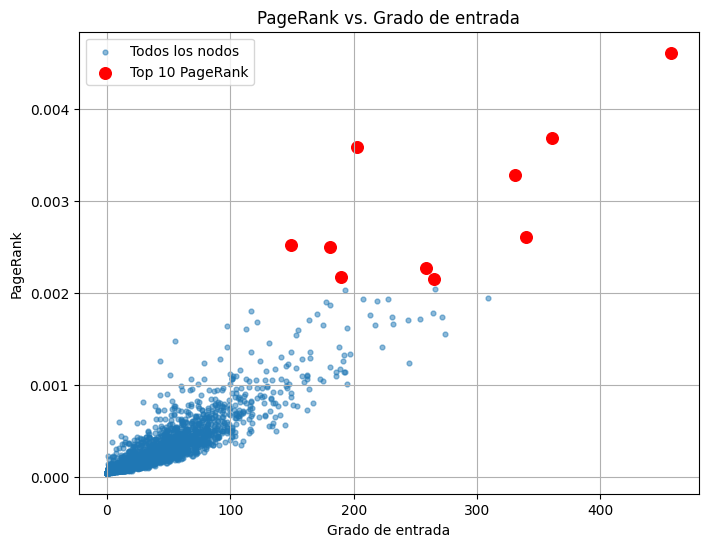

In [39]:
ranking = np.argsort(-pagerank)

top10 = ranking[:10]

plt.figure(figsize=(8,6))

plt.scatter(
    in_degree,
    pagerank,
    s=12,
    alpha=0.5,
    label="Todos los nodos"
)

plt.scatter(
    in_degree[top10],
    pagerank[top10],
    color="red",
    s=70,
    label="Top 10 PageRank"
)

plt.xlabel("Grado de entrada")
plt.ylabel("PageRank")
plt.title("PageRank vs. Grado de entrada")

plt.grid(True)
plt.legend()

plt.show()

# Ahora vemos la correlacion de Pearson

In [40]:
correlacion = np.corrcoef(in_degree, pagerank)[0,1]

print(f"Correlación de Pearson: {correlacion:.4f}")

Correlación de Pearson: 0.9223


# La correlacion de Pearson nos muestra una fuerte relacion entre el grado de entrada y el PageRank con nuestros datos


# Ahora buscamos nodos que difieren significativamente con su PageRank

In [41]:
df = pd.DataFrame({
    "Nodo": nodos,
    "PageRank": pagerank,
    "Grado entrada": in_degree,
    "Grado salida": out_degree
})

print("Nodos con mucho grado y poco PageRank")
df.sort_values(
    "Grado entrada",
    ascending=False
).head(20)
      

Nodos con mucho grado y poco PageRank


,Nodo,PageRank,Grado entrada,Grado salida
326,4037,0.004607,457,15
409,15,0.003680,361,50
905,2398,0.002609,340,62
711,2625,0.003284,331,0
247,1297,0.001946,309,76
699,2565,0.001551,274,893
432,762,0.001742,272,50
666,2328,0.002039,266,215
3,5254,0.002150,265,33
2,3352,0.001784,264,273


In [42]:
print("Nodos con mucho PageRank y grado moderado")
df.sort_values(
    "PageRank",
    ascending=False
).head(20)

Nodos con mucho PageRank y grado moderado


,Nodo,PageRank,Grado entrada,Grado salida
326,4037,0.004607,457,15
409,15,0.003680,361,50
1332,6634,0.003587,203,3
711,2625,0.003284,331,0
905,2398,0.002609,340,62
686,2470,0.002524,149,0
656,2237,0.002497,181,241
1141,4191,0.002268,259,20
1261,7553,0.002170,190,0
3,5254,0.002150,265,33


# Top 10

In [43]:
df["Ranking PR"] = df["PageRank"].rank(
    ascending=False,
    method="min"
)

df["Ranking InDegree"] = df["Grado entrada"].rank(
    ascending=False,
    method="min"
)
df["Diferencia"] = df["Ranking InDegree"] - df["Ranking PR"]
print("Mayor PageRank que grado:")
display(df.sort_values("Diferencia", ascending=False).head(10))

print("Mayor grado que PageRank:")
display(df.sort_values("Diferencia").head(10))

Mayor PageRank que grado:


,Nodo,PageRank,Grado entrada,Grado salida,Ranking PR,Ranking InDegree,Diferencia
1122,2185,0.000595,10,0,288.0,1907.0,1619.0
3193,3201,0.000385,4,0,622.0,2168.0,1546.0
10,108,0.000445,11,2,485.0,1863.0,1378.0
2189,565,0.000310,7,1,842.0,2028.0,1186.0
1,1412,0.000814,29,0,146.0,1322.0,1176.0
105,10,0.000427,15,86,535.0,1706.0,1171.0
1237,930,0.000586,24,0,296.0,1449.0,1153.0
4560,4886,0.000228,1,0,1166.0,2304.0,1138.0
3477,5231,0.000361,12,0,689.0,1819.0,1130.0
28,8283,0.000315,10,0,820.0,1907.0,1087.0


Mayor grado que PageRank:


,Nodo,PageRank,Grado entrada,Grado salida,Ranking PR,Ranking InDegree,Diferencia
525,1413,0.000230,70,0,1159.0,426.0,-733.0
1419,5637,0.000191,58,0,1346.0,618.0,-728.0
931,2828,0.000194,58,0,1329.0,618.0,-711.0
459,946,0.000207,61,110,1264.0,556.0,-708.0
1553,3251,0.000210,62,0,1251.0,544.0,-707.0
1364,1792,0.000204,60,31,1275.0,577.0,-698.0
2029,4797,0.000236,69,0,1130.0,434.0,-696.0
1685,3338,0.000184,55,3,1371.0,685.0,-686.0
725,2754,0.000251,72,0,1070.0,398.0,-672.0
292,1573,0.000197,57,0,1307.0,639.0,-668.0


# Bibliografía : 
- Recursos python. (2021). Compresión y descompresión de archivos zip, gz y bz2. Recursos python. https://recursospython.com/guias-y-manuales/compresion-y-descompresion-de-archivos/
- Carazo,F. & Amat,Joaquin. (2024). Métricas de Grafos y Redes. Ciencia de datos. https://cienciadedatos.net/documentos/pygml04-metricas-grafos-redes-python
- Moiz, M.S . (2023). Cómo encontrar el valor máximo en el Diccionario Python. DelftStack. https://www.delftstack.com/es/howto/python/find-max-value-in-dictionary-python/
- Raj, A. (2023). Matriz dispersa en Python. DelfStack. https://www.delftstack.com/es/howto/python/sparse-matrix-in-python/
- Stack Over Flow. (2023). Ignore divide by 0 warning in NumPy. Stack Over Flow . https://stackoverflow.com/questions/29950557/ignore-divide-by-0-warning-in-numpy


- LINK IMPORTANTE : https://people.duke.edu/~ccc14/sta-663-2017/13E_SparseMatrices.html#application-pagerank.
- De este link sacamos que la matriz H se puede calcular como (Adj @ D)**T